# Cochlear implant simulation 

**Acoustic analysis, CIS encoding and acoustic reconstruction**  
**BME 576 Sensory Prostheses Engineering**  
Gianluigi D’Antonio · Gabriele Colò · Yelizaveta Semikina

This notebook is the complete project presented as one continuous document. Part 1 starts from speech and music recordings, separates them into four frequency bands, extracts temporal envelopes and applies logarithmic compression. Part 2 converts the compressed envelopes into charge-balanced, interleaved CIS pulse trains. Part 3 decodes the pulse samples and uses them to drive a four-channel noise vocoder.

The detailed Part 1 analysis is kept intact and now feeds the commented Parts 2 and 3 through the shared `records` structure. The decoder reads the pulse trains, rather than cached amplitudes or the original envelopes. The reconstructed audio is an acoustic illustration of the information preserved by this simplified model. It is not an exact waveform reconstruction, a clinical implant simulation or a prediction of an individual listener’s perception.

## How to use this notebook

Run the cells from top to bottom in the project root. The first audio-loading cell may download the example recordings through `librosa`. The final export cell writes WAV files and a JSON summary under `results/part3/`.


## 1. Shared setup and parameters

The audio clock and the stimulation clock are different. Audio is sampled at 22,050 Hz, while the four-channel CIS encoder uses a 100,000 Hz stimulation grid. The four analysis bands are 200–500, 500–1,250, 1,250–3,150 and 3,150–8,000 Hz. The envelope cutoff is 400 Hz and the logarithmic compression parameter is α = 1,000.

The pulse settings below are the four-channel base configuration. The 8-, 16- and 32-channel versions used by the listening game use a separate timing configuration.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import soundfile as sf
from IPython.display import Audio, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "cis.py").is_file():
    raise FileNotFoundError(
        "Open this notebook in the repository root on part3-reconstruction "
        "or another branch containing src/cis.py."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.audio import load_example_audio, load_audio_file
from src.visualization import (
    plot_frequency_spectrum, plot_psd, compute_band_power,
    plot_filterbank_waveforms, plot_filterbank_psd, plot_envelopes,
)
from src.preprocessing import preprocess_audio
from src.filterbank import apply_filterbank
from src.envelope import full_wave_rectify, extract_envelopes
from src.compression import compress_envelopes
from src.cis import encode_cis, plot_cis
from src.reconstruction import (
    extract_pulse_amplitudes,
    inverse_logarithmic_compression,
    interpolate_envelopes,
    noise_vocoder,
    reconstruct_audio,
)

AUDIO_FS = 22050
BAND_EDGES = [200, 500, 1250, 3150, 8000]
FILTER_ORDER = 4
ENVELOPE_CUTOFF = 400
ALPHA = 1000.0
DURATION = 8.0
examples = [("speech", "libri1", 0.0), ("music", "brahms", 15.0)]
STIMULATION_FS = 100000
PULSE_RATE = 1000
PHASE_DURATION_US = 50
INTERPHASE_GAP_US = 0
NOISE_SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "results" / "part3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 2. Part 1 · audio input and preprocessing

We use one eight-second speech excerpt and one eight-second music excerpt, both resampled to 22,050 Hz. Preprocessing removes the DC component and applies one global peak normalization to each complete recording. No independent normalization is applied to individual channels later, so relative band energies remain visible throughout the pipeline.


22050 (176400,)
22050 (176400,)
Speech:


Music:


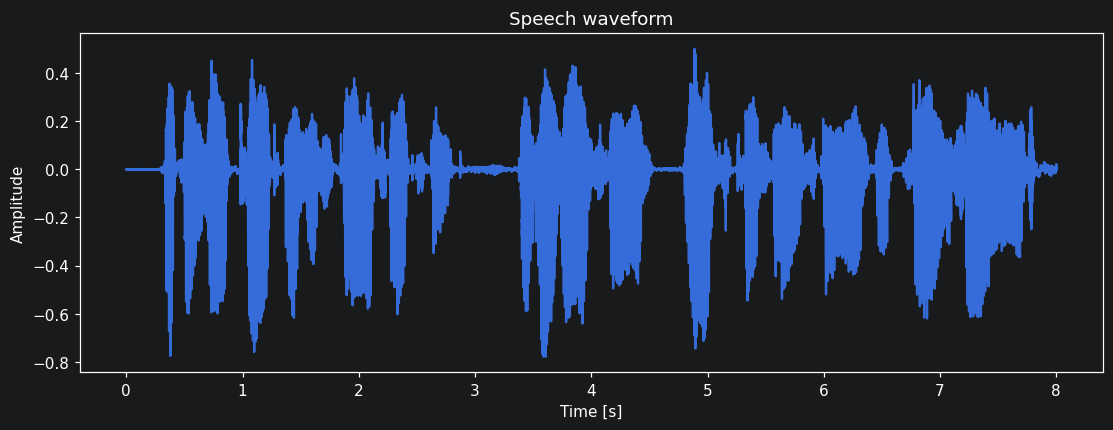

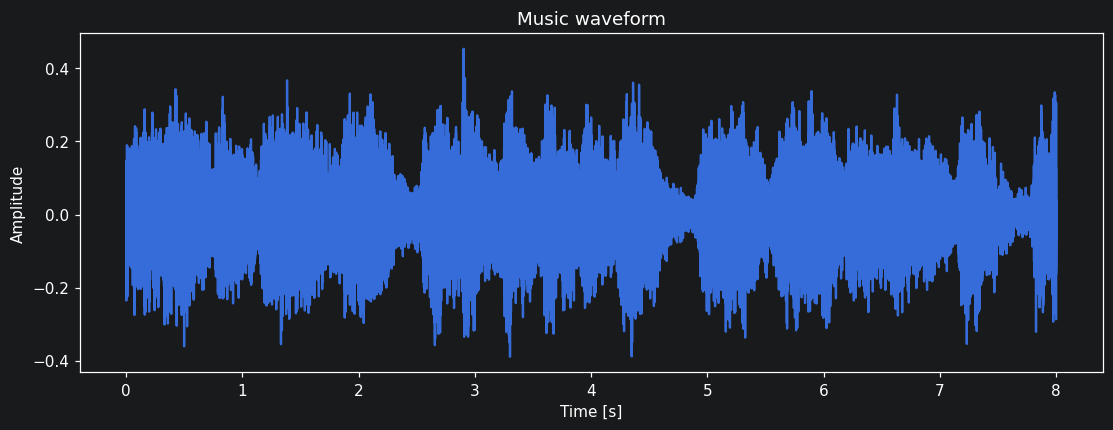

In [2]:
# Load the speech and music examples and inspect their waveforms.
speech, fs_speech = load_example_audio(
    "libri1",
    sr=22050,
    duration=8.0
)

music, fs_music = load_example_audio(
    "brahms",
    sr=22050,
    duration=8.0,
    offset=15.0
)

print(fs_speech, speech.shape)
print(fs_music, music.shape)

print("Speech:")
display(Audio(speech, rate=fs_speech))

print("Music:")
display(Audio(music, rate=fs_music))

time_speech = np.arange(len(speech)) / fs_speech
time_music = np.arange(len(music)) / fs_music

plt.figure(figsize=(12, 4))
plt.plot(time_speech, speech)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_music, music)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Music waveform")
plt.show()

### 2.1 Preprocessing

The processed signals are the inputs to all later stages. The mean should be close to zero and the peak magnitude should be at most one after normalization.


In [3]:
# Remove the DC component and apply one global normalization to each recording.
speech_processed = preprocess_audio(speech)
music_processed = preprocess_audio(music)

print("Speech")
print("Mean before:", np.mean(speech))
print("Mean after :", np.mean(speech_processed))
print("Peak after :", np.max(np.abs(speech_processed)))

print("\nMusic")
print("Mean before:", np.mean(music))
print("Mean after :", np.mean(music_processed))
print("Peak after :", np.max(np.abs(music_processed)))

from IPython.display import Audio, display

print("Original speech:")
display(Audio(speech, rate=fs_speech))

print("Processed speech:")
display(Audio(speech_processed, rate=fs_speech))

Speech
Mean before: 7.8427925e-05
Mean after : 1.4867371e-10
Peak after : 1.0

Music
Mean before: -3.593373e-05
Mean after : -1.0461223e-09
Peak after : 1.0
Original speech:


Processed speech:


### 2.2 Frequency-domain overview

Frequency spectra and Welch power spectral densities show how the speech and music excerpts distribute energy across the 200–8,000 Hz analysis range. The band-power table provides a numerical summary before the filter bank is applied.


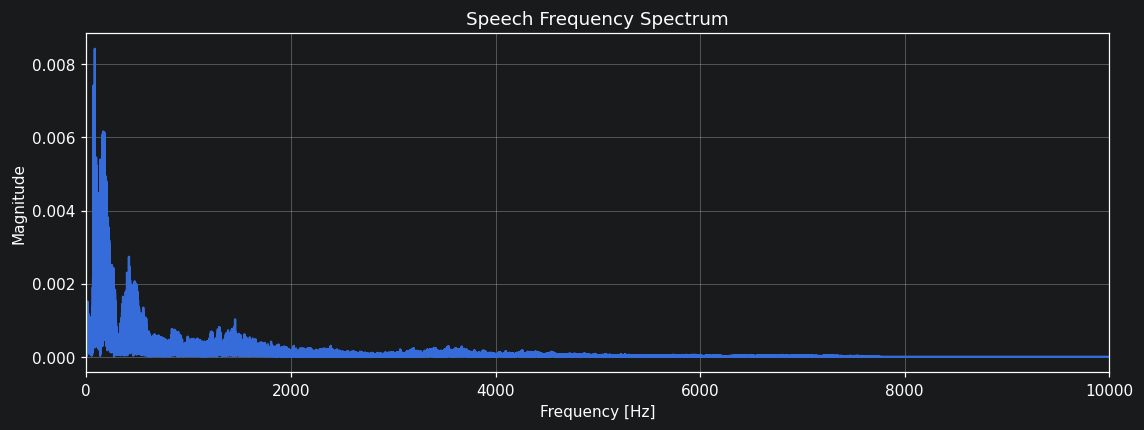

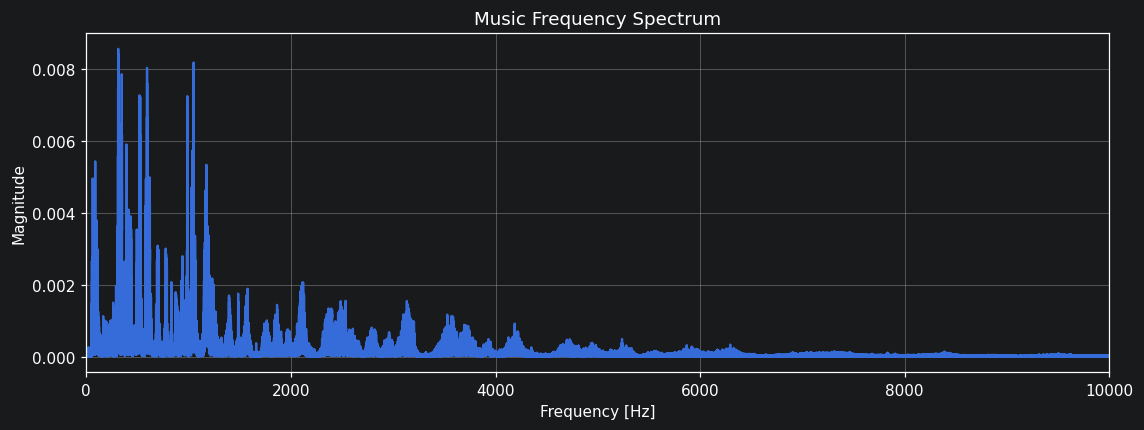

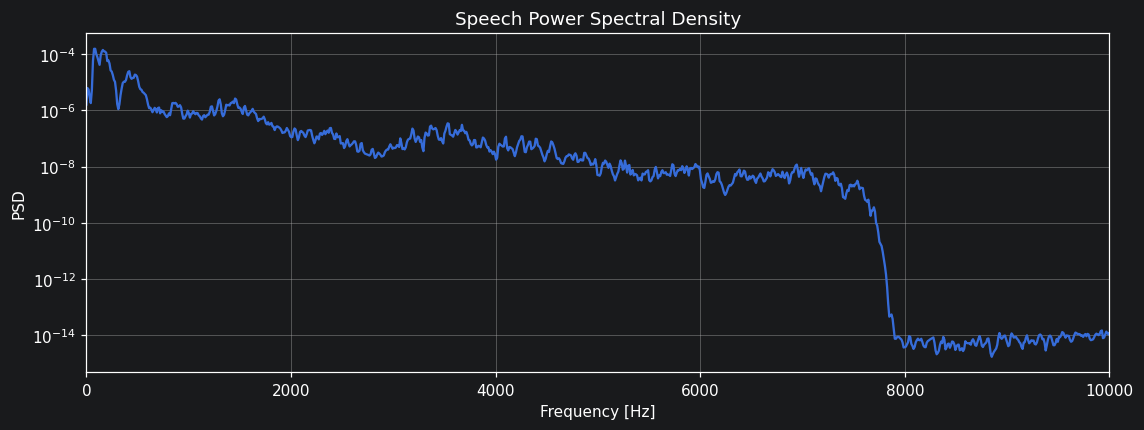

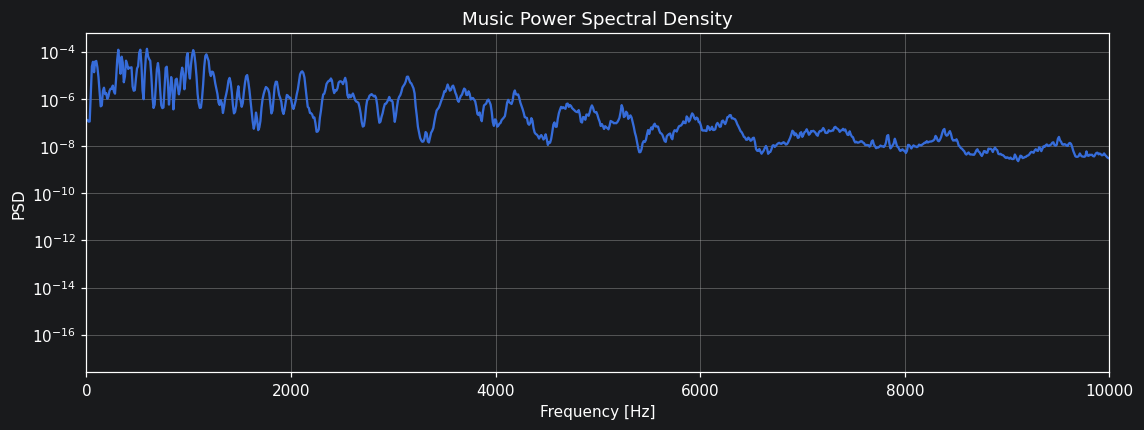

Band [Hz]           Speech [%]   Music [%]
------------------------------------------
200-500                  71.30       19.45
500-1250                 15.66       61.74
1250-3150                10.70       13.75
3150-8000                 2.35        5.06


In [4]:
# Inspect spectra, PSDs and relative power in the four assignment bands.
plot_frequency_spectrum(
    speech_processed,
    fs_speech,
    title="Speech Frequency Spectrum",
    max_freq=10000
)

plot_frequency_spectrum(
    music_processed,
    fs_music,
    title="Music Frequency Spectrum",
    max_freq=10000
)


plot_psd(
    speech_processed,
    fs_speech,
    title="Speech Power Spectral Density"
)

plot_psd(
    music_processed,
    fs_music,
    title="Music Power Spectral Density"
)


band_edges = [200, 500, 1250, 3150, 8000]

speech_band_power = compute_band_power(
    speech_processed,
    fs_speech,
    band_edges
)

music_band_power = compute_band_power(
    music_processed,
    fs_music,
    band_edges
)

print(f"{'Band [Hz]':<18}{'Speech [%]':>12}{'Music [%]':>12}")
print("-" * 42)

for i in range(len(band_edges) - 1):
    band = f"{band_edges[i]}-{band_edges[i+1]}"

    print(
        f"{band:<18}"
        f"{speech_band_power[i]:>12.2f}"
        f"{music_band_power[i]:>12.2f}"
    )

### 2.3 Four-band filter bank

The four project-defined bands are processed independently with Butterworth band-pass filters. In SciPy, `butter(N=4, btype="bandpass")` produces an eighth-order band-pass response in one pass and is represented by four second-order sections. The forward-backward implementation is offline and zero phase.


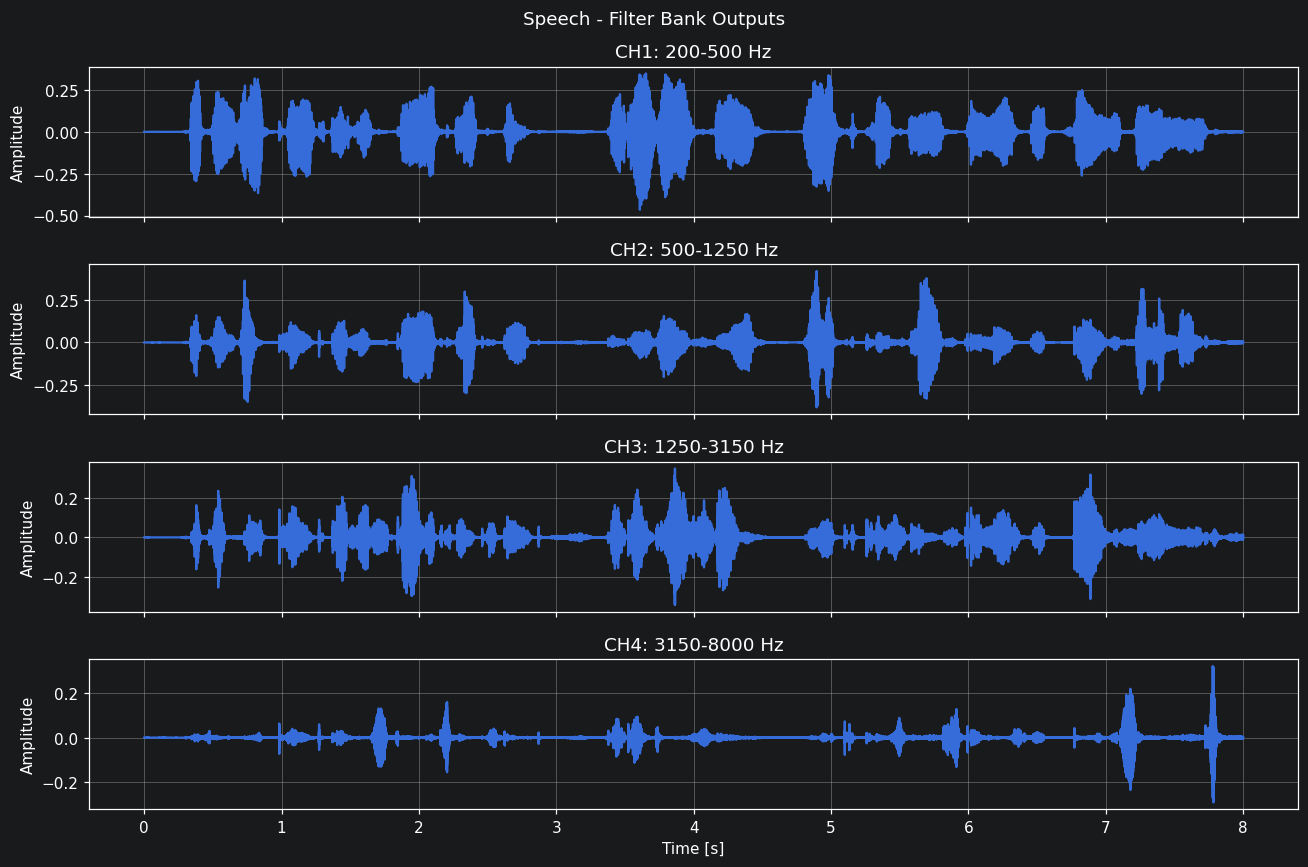

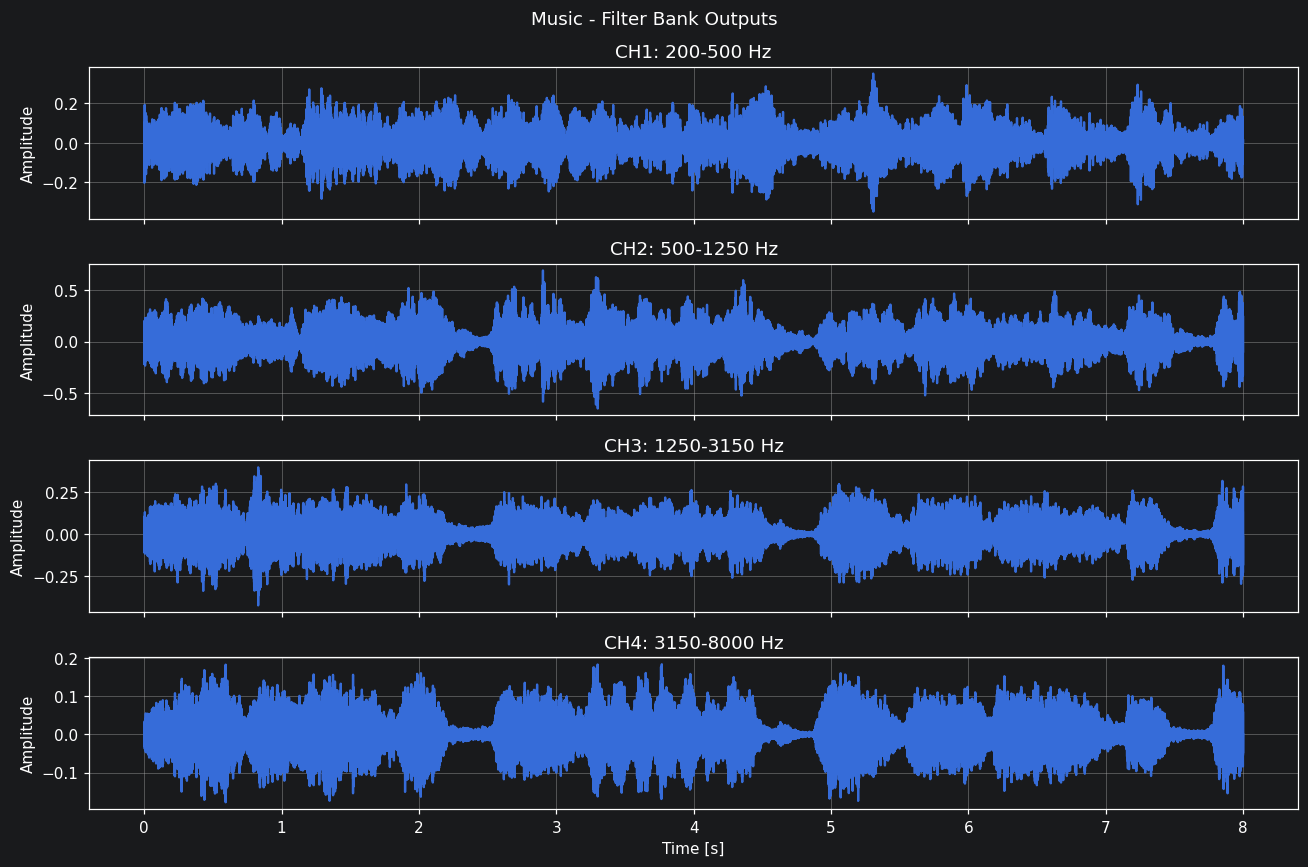

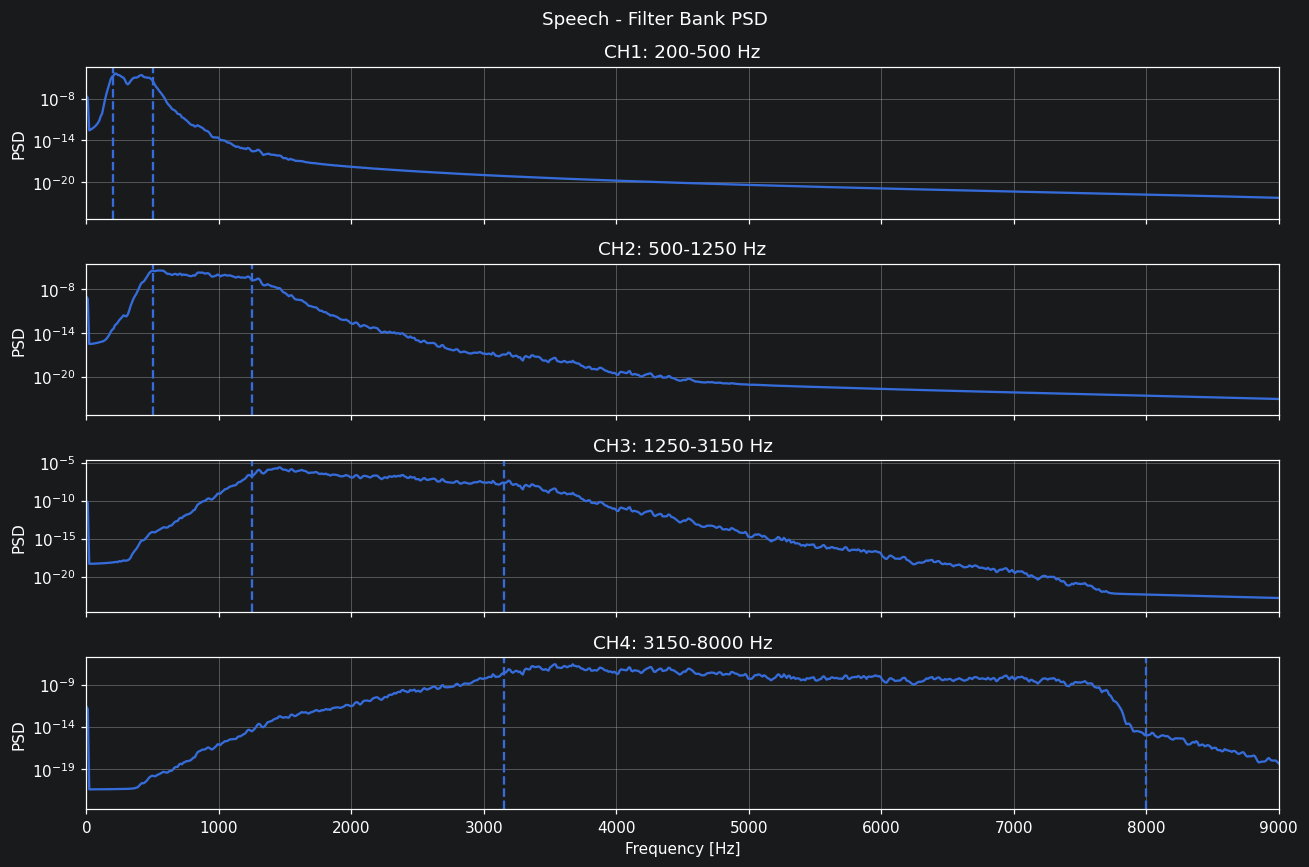

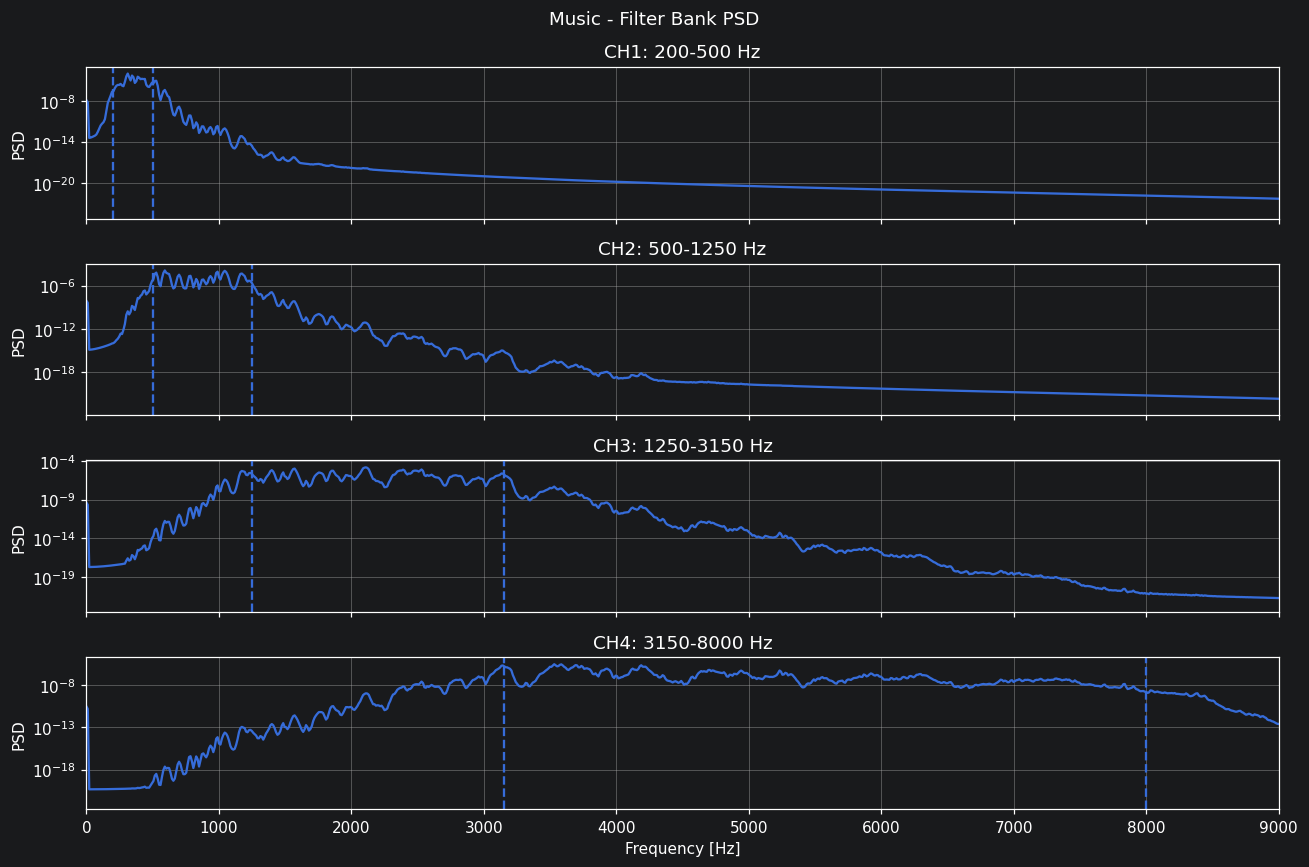

In [5]:
# Apply the four-band filter bank and visualize the channel waveforms and PSDs.
band_edges = [200, 500, 1250, 3150, 8000]

speech_channels = apply_filterbank(
    speech_processed,
    fs_speech,
    band_edges
)

music_channels = apply_filterbank(
    music_processed,
    fs_music,
    band_edges
)

plot_filterbank_waveforms(
    speech_channels,
    fs_speech,
    band_edges,
    title="Speech - Filter Bank Outputs"
)

plot_filterbank_waveforms(
    music_channels,
    fs_music,
    band_edges,
    title="Music - Filter Bank Outputs"
)

plot_filterbank_psd(
    speech_channels,
    fs_speech,
    band_edges,
    title="Speech - Filter Bank PSD"
)

plot_filterbank_psd(
    music_channels,
    fs_music,
    band_edges,
    title="Music - Filter Bank PSD"
)

### 2.4 Envelope extraction

Each band is full-wave rectified and then low-pass filtered at a nominal 400 Hz cutoff. The envelope function clips negative values after filtering so that the signal passed to compression remains in [0, 1]. Before clipping, small negative undershoots can occur because of filter ringing.

The low-pass filter is applied forward and backward with `sosfiltfilt`. Therefore, the final magnitude response is squared. The 400 Hz value is the nominal single-pass cutoff, not the final half-power frequency of the complete forward-backward response.


Envelope ranges before compression

Speech
CH1: min=0.000000, max=0.316832
CH2: min=0.000000, max=0.244291
CH3: min=0.000000, max=0.221613
CH4: min=0.000000, max=0.141306

Music
CH1: min=0.000329, max=0.229571
CH2: min=0.000822, max=0.381536
CH3: min=0.001228, max=0.217649
CH4: min=0.000318, max=0.096334


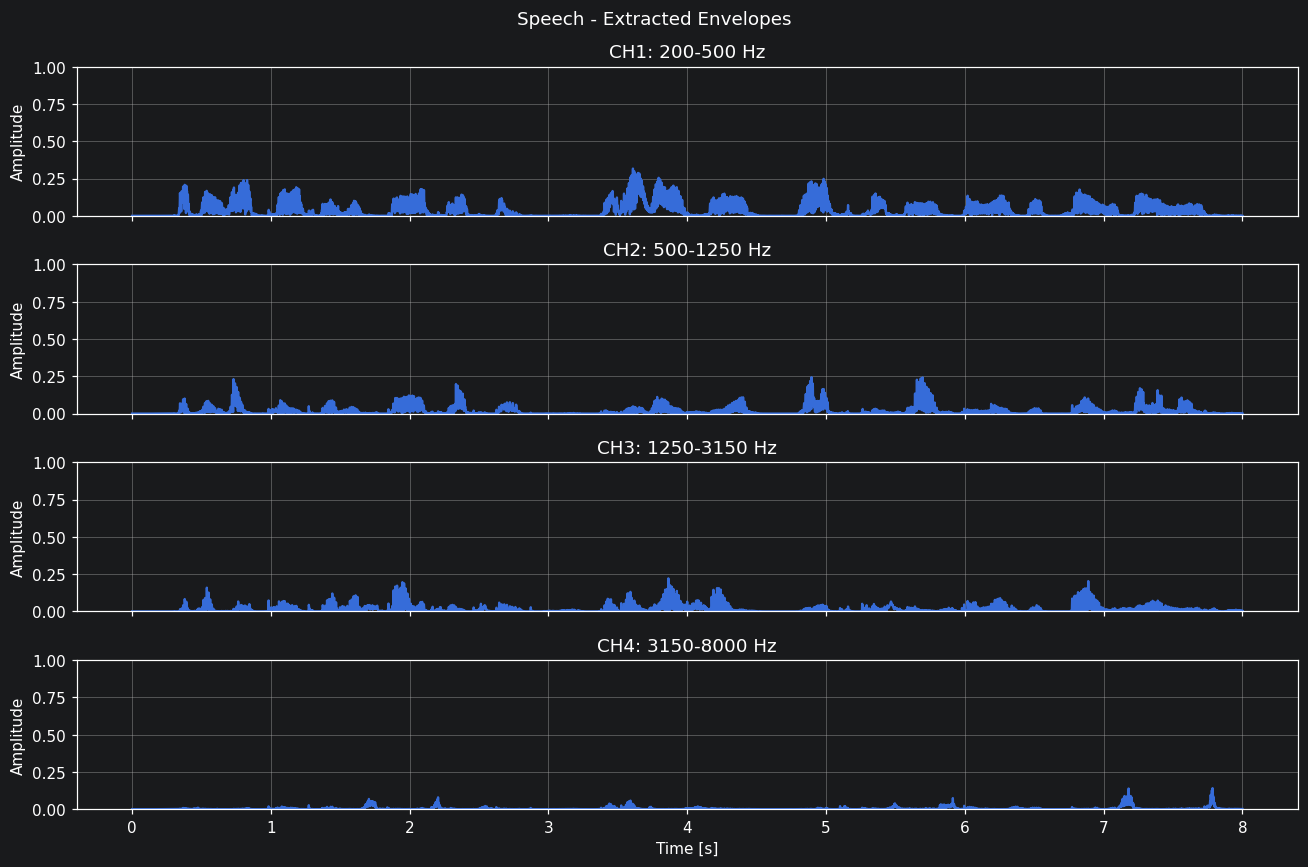

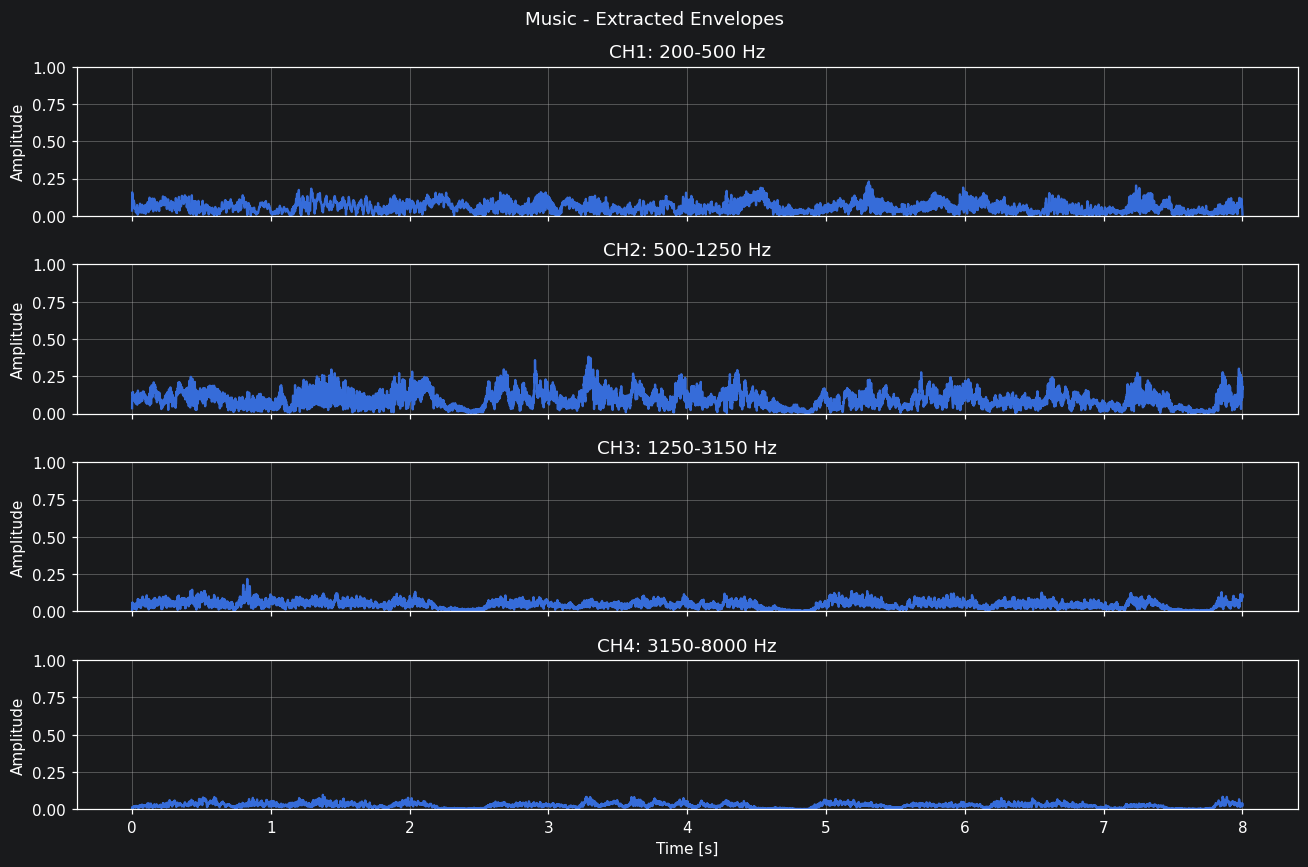

In [6]:
# Extract and visualize the four temporal envelopes.
speech_envelopes = extract_envelopes(
    speech_channels,
    fs_speech,
    cutoff=400
)

music_envelopes = extract_envelopes(
    music_channels,
    fs_music,
    cutoff=400
)

print("Envelope ranges before compression")

for name, envelopes in [
    ("Speech", speech_envelopes),
    ("Music", music_envelopes)
]:
    print(f"\n{name}")

    for i, env in enumerate(envelopes):
        print(
            f"CH{i+1}: "
            f"min={np.min(env):.6f}, "
            f"max={np.max(env):.6f}"
        )

assert all(
    np.all((env >= 0) & (env <= 1))
    for env in speech_envelopes + music_envelopes
)

channel_index = 0

channel = speech_channels[channel_index]
rectified = full_wave_rectify(channel)
envelope = speech_envelopes[channel_index]

start_time = 3.5
end_time = 4.0

start_sample = int(start_time * fs_speech)
end_sample = int(end_time * fs_speech)

time = np.arange(start_sample, end_sample) / fs_speech

plot_envelopes(
    speech_envelopes,
    fs_speech,
    band_edges,
    title="Speech - Extracted Envelopes"
)

plot_envelopes(
    music_envelopes,
    fs_music,
    band_edges,
    title="Music - Extracted Envelopes"
)

### 2.5 Logarithmic compression

The compressed envelope is

\[
c = \frac{\ln(1+\alpha e)}{\ln(1+\alpha)}.
\]

We use α = 1,000, adopted from the documented FS4 reference setting. This is an explicit modeling choice for the assignment, not a universal CIS parameter. Compression expands the relative representation of weak envelope values while reducing the dynamic range of stronger values.


Compressed envelope ranges

Speech
CH1: min=0.000000, max=0.833945
CH2: min=0.000000, max=0.796445
CH3: min=0.000000, max=0.782404
CH4: min=0.000000, max=0.717637

Music
CH1: min=0.041199, max=0.787488
CH2: min=0.086810, max=0.860766
CH3: min=0.115946, max=0.779803
CH4: min=0.039935, max=0.662659


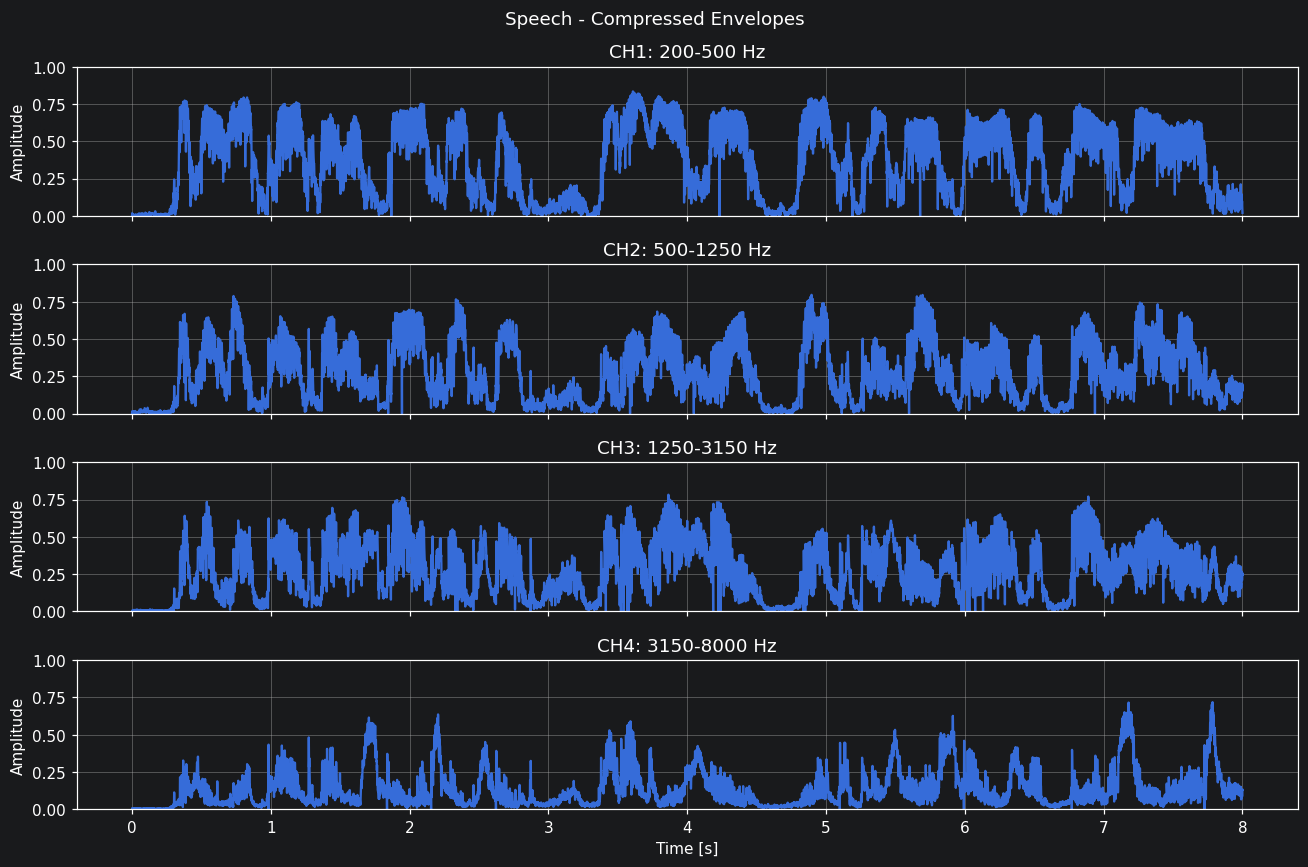

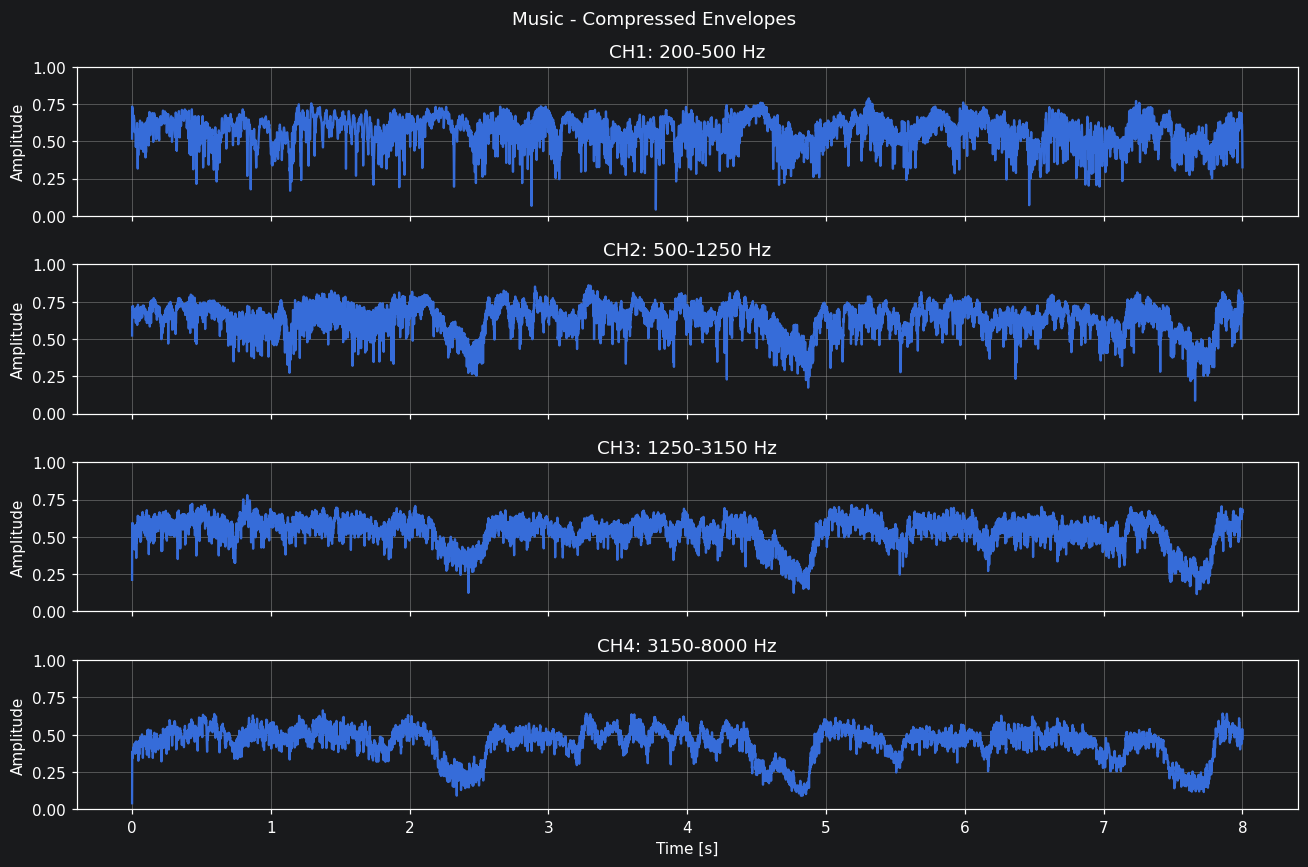

In [7]:
# Apply logarithmic compression and verify the compressed envelope ranges.
alpha = 1000.0

speech_compressed_envelopes = compress_envelopes(
    speech_envelopes,
    alpha=alpha
)

music_compressed_envelopes = compress_envelopes(
    music_envelopes,
    alpha=alpha
)

print("Compressed envelope ranges")

for name, envelopes in [
    ("Speech", speech_compressed_envelopes),
    ("Music", music_compressed_envelopes)
]:
    print(f"\n{name}")

    for i, env in enumerate(envelopes):
        print(
            f"CH{i+1}: "
            f"min={np.min(env):.6f}, "
            f"max={np.max(env):.6f}"
        )

assert all(
    np.all((env >= 0) & (env <= 1))
    for env in speech_compressed_envelopes + music_compressed_envelopes
)

plot_envelopes(
    speech_compressed_envelopes,
    fs_speech,
    band_edges,
    title="Speech - Compressed Envelopes"
)

plot_envelopes(
    music_compressed_envelopes,
    fs_music,
    band_edges,
    title="Music - Compressed Envelopes"
)

In [8]:
# Connect the detailed Part 1 outputs to the shared structure used in Parts 2 and 3.
records = {
    "speech": {
        "original": speech_processed,
        "fs": fs_speech,
        "reference_envelopes": np.asarray(speech_envelopes),
        "reference_compressed": np.asarray(speech_compressed_envelopes),
    },
    "music": {
        "original": music_processed,
        "fs": fs_music,
        "reference_envelopes": np.asarray(music_envelopes),
        "reference_compressed": np.asarray(music_compressed_envelopes),
    },
}
print("Part 1 complete: records prepared for CIS encoding.")


Part 1 complete: records prepared for CIS encoding.


## 3. Part 2 · Continuous Interleaved Sampling

The compressed envelope samples control the amplitudes of charge-balanced biphasic pulses. Each channel emits 1,000 pulses/s. With a 100,000 Hz stimulation sampling rate, each 50 µs phase occupies five samples, and the four channel slots begin at 0, 25, 50 and 75 samples within each 1 ms frame. The pulses are interleaved so that no two channels are active at the same time.

The amplitudes are normalized simulation values. They are not calibrated current amplitudes and should not be interpreted as clinical stimulation settings.


In [9]:
# Encode the compressed envelopes produced in Part 1 as interleaved CIS pulses.
for name, record in records.items():
    record["cis"] = encode_cis(
        record["reference_compressed"], record["fs"],
        stimulation_fs=STIMULATION_FS,
        pulse_rate=PULSE_RATE,
        phase_duration_us=PHASE_DURATION_US,
        interphase_gap_us=INTERPHASE_GAP_US,
    )
    cis = record["cis"]
    print(
        f"{name}: {cis.pulses.shape[0]} channels, "
        f"{cis.onset_samples.shape[1]} pulses per channel"
    )


speech: 4 channels, 8000 pulses per channel
music: 4 channels, 8000 pulses per channel


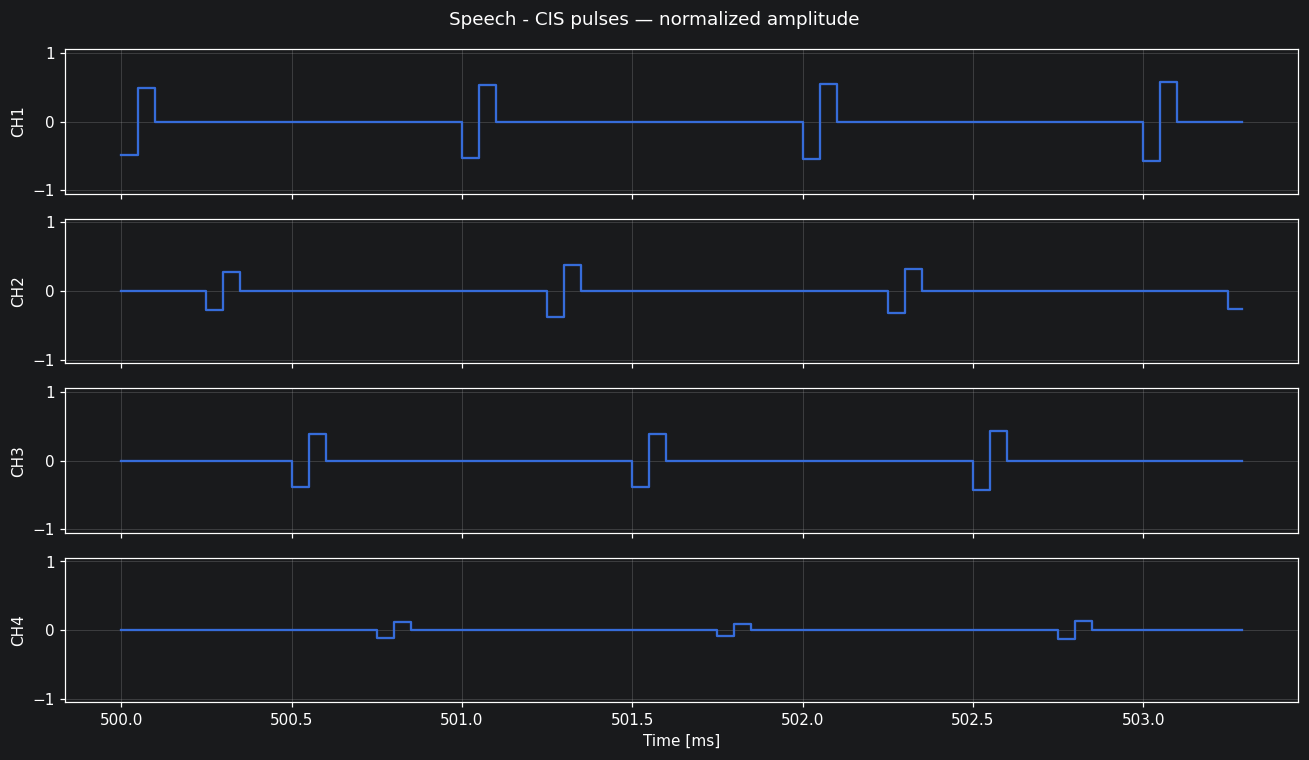

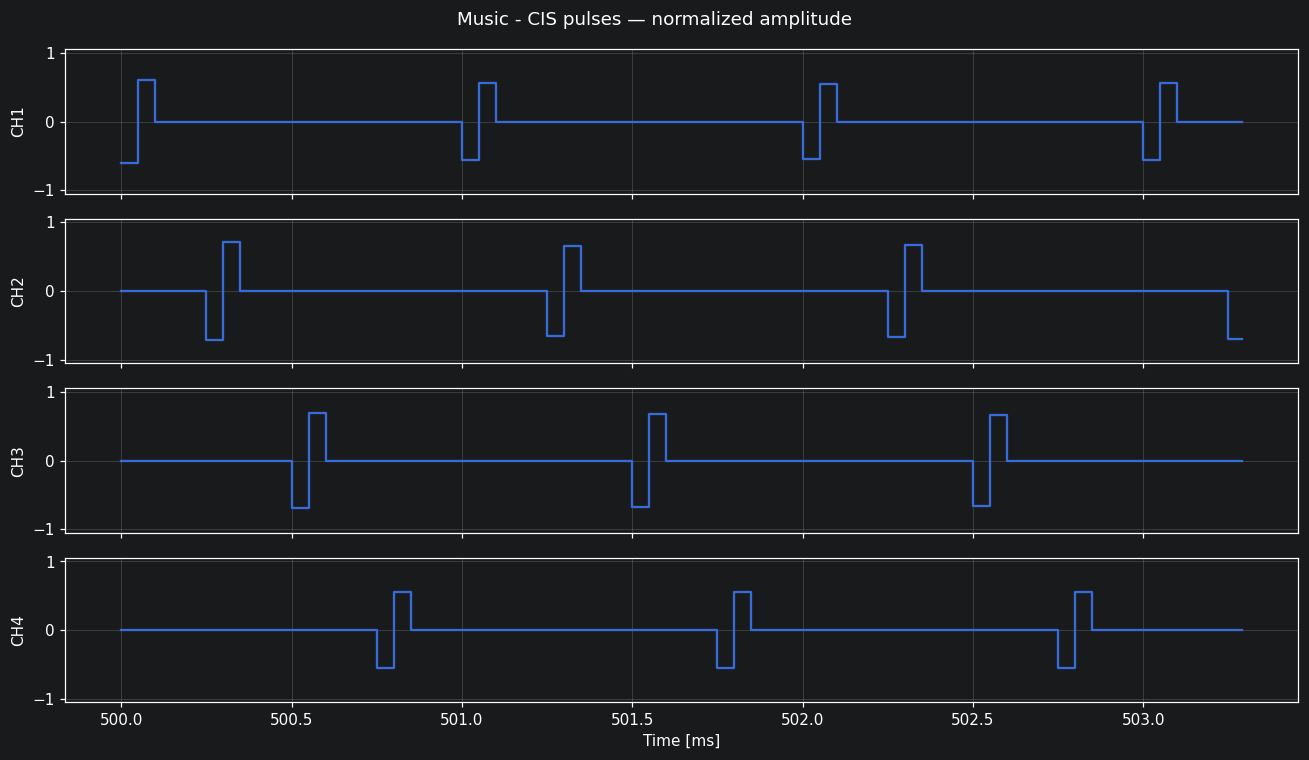

In [10]:
for name, record in records.items():
    fig = plot_cis(
        record["cis"], start=0.5, duration=0.0033,
        title=f"{name.capitalize()} - CIS pulses"
    )
    fig.savefig(OUTPUT_DIR / f"{name}_cis.png", dpi=160)
    plt.show()
    plt.close(fig)

### 4.1 Recover samples from the pulse trains

Each pulse contains a negative phase and a positive phase of equal magnitude.
The encoder holds one compressed-envelope value across both phases. We average
only the positive phase to recover it. Averaging the whole signed pulse would
give zero because the phases cancel.

The decoder uses `onset_samples`, `phase_samples` and `gap_samples` to locate
the positive phase, including pulses with zero amplitude. It does not read
the cached `cis.amplitudes` array.

The check below independently computes the expected compressed-envelope sample
at each channel's actual pulse onset. Agreement verifies pulse decoding, not
perfect reconstruction of the original sound.

In [11]:
for name, record in records.items():
    cis = record["cis"]
    recovered = extract_pulse_amplitudes(cis)
    audio_time = np.arange(cis.input_samples) / record["fs"]
    expected = np.array([
        np.interp(starts / cis.stimulation_fs, audio_time,
                  record["reference_compressed"][channel])
        for channel, starts in enumerate(cis.onset_samples)
    ])
    np.testing.assert_allclose(recovered, expected, rtol=0, atol=1e-12)
    record["sampled_compressed"] = recovered
    record["pulse_max_error"] = float(np.max(np.abs(recovered - expected)))
    print(f"{name}: maximum pulse-amplitude error = "
          f"{record['pulse_max_error']:.3e}")

speech: maximum pulse-amplitude error = 1.110e-16
music: maximum pulse-amplitude error = 1.110e-16


## 4. Part 3 · acoustic reconstruction

The decoder reverses the logarithmic compression, interpolates the recovered envelope samples onto the audio grid and uses them to modulate independent band-limited noise carriers. The four synthesized channels are summed to produce the reconstruction.

The inverse mapping is exact for the compression formula, but continuous-envelope recovery remains approximate because the encoder samples compressed values at discrete times and the decoder uses linear interpolation with boundary holding.


### 4.2 Inverse logarithmic compression and interpolation

The encoder uses

\[
c = \frac{\ln(1+\alpha e)}{\ln(1+\alpha)}.
\]

We apply its inverse to each recovered pulse sample,

\[
\hat e = \frac{\exp(c\ln(1+\alpha))-1}{\alpha},
\]

then linearly interpolate these samples to the original audio sampling grid.
Each channel has its own staggered pulse times. For example, the default second
channel starts at 0.25 ms, not at 0 ms.

At the boundaries, the nearest recovered sample is held constant, including any
trailing partial frame omitted by the encoder. If no complete frame was encoded,
the decoder returns silence. These are explicit boundary assumptions.

The inverse is exact for the log mapping, but the overall envelope recovery is
approximate. The encoder interpolates *compressed* values before sampling, the
inverse is nonlinear, and the decoder uses linear interpolation. A 400 Hz
low-pass cutoff also does not imply a perfectly band-limited envelope.

In [12]:
for record in records.values():
    cis = record["cis"]
    sampled = inverse_logarithmic_compression(
        record["sampled_compressed"], alpha=ALPHA
    )
    recovered_envelopes = interpolate_envelopes(
        sampled, cis.onset_samples, cis.stimulation_fs,
        record["fs"], cis.input_samples
    )
    record["sampled_envelopes"] = sampled
    record["recovered_envelopes"] = recovered_envelopes

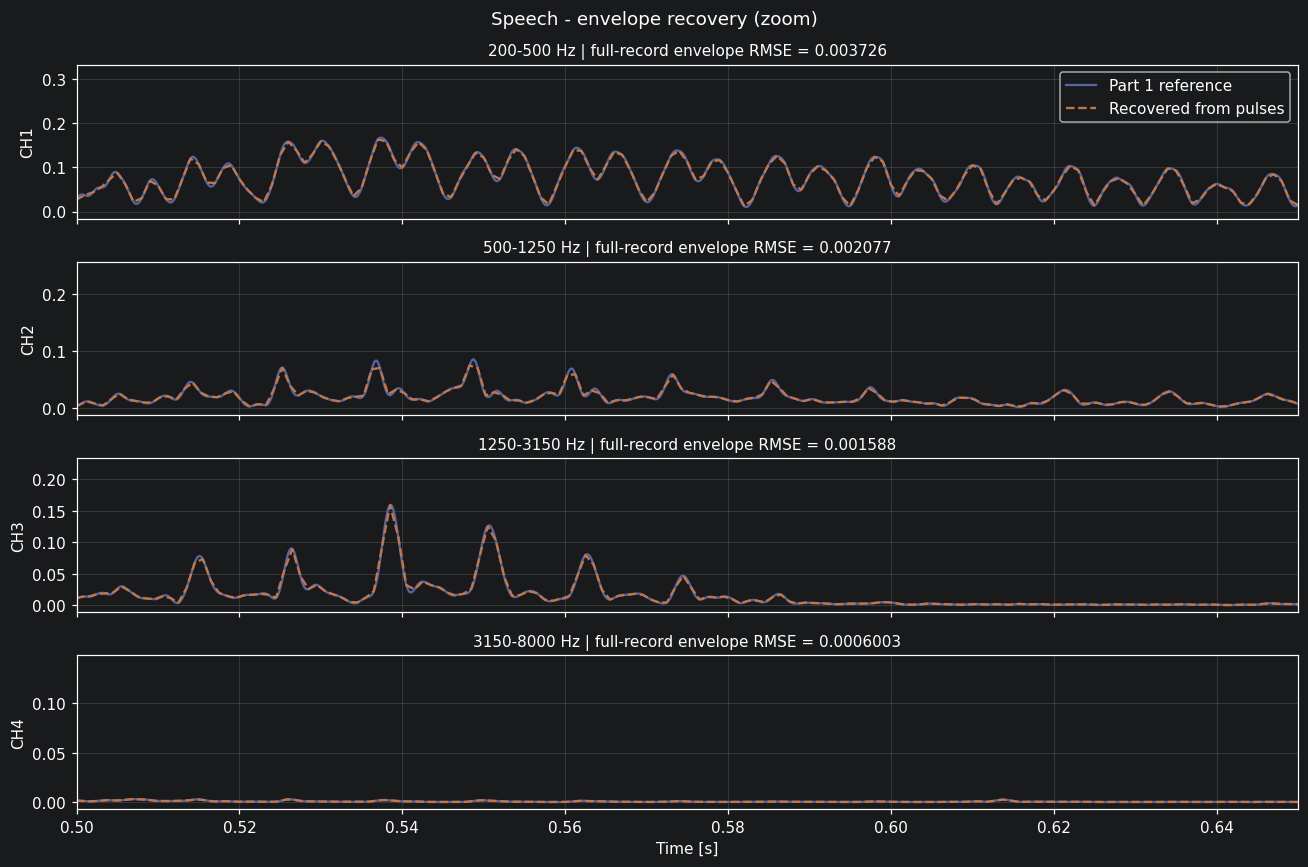

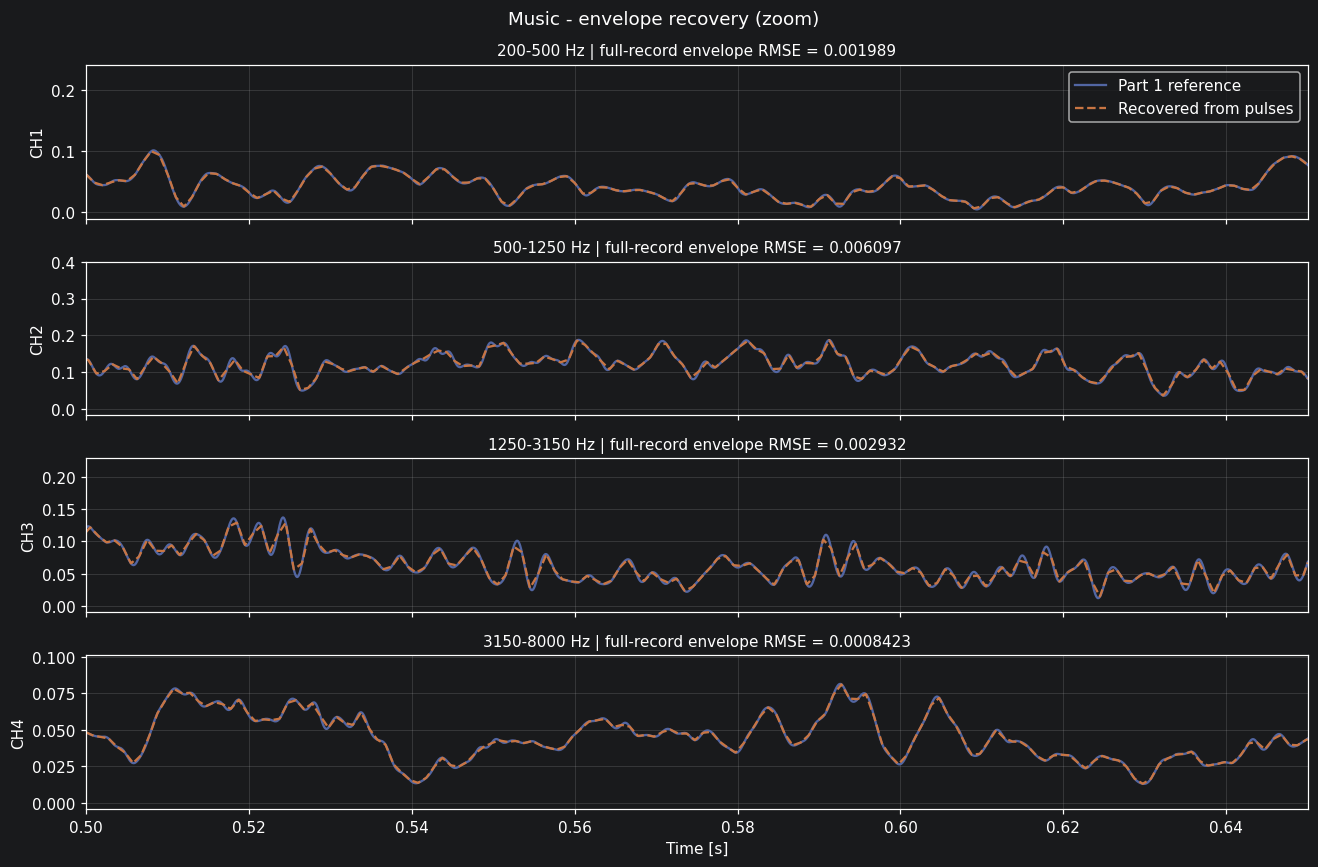

In [13]:
for name, record in records.items():
    time = np.arange(len(record["original"])) / record["fs"]
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    errors = record["recovered_envelopes"] - record["reference_envelopes"]
    rmse = np.sqrt(np.mean(errors ** 2, axis=1))
    record["envelope_rmse"] = rmse.tolist()
    for channel, ax in enumerate(axes):
        ax.plot(time, record["reference_envelopes"][channel],
                label="Part 1 reference", color="#5266a3", linewidth=1.5)
        ax.plot(time, record["recovered_envelopes"][channel],
                label="Recovered from pulses", color="#c87543", linestyle="--")
        ax.set_ylabel(f"CH{channel + 1}")
        ax.set_xlim(0.5, 0.65)
        ax.grid(alpha=0.25)
        ax.set_title(f"{BAND_EDGES[channel]}-{BAND_EDGES[channel + 1]} Hz "
                     f"| full-record envelope RMSE = {rmse[channel]:.4g}", fontsize=10)
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(f"{name.capitalize()} - envelope recovery (zoom)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{name}_envelopes.png", dpi=160)
    plt.show()
    plt.close(fig)

### 4.3 Noise-vocoder synthesis

For each band we generate an independent noise carrier, filter it to the same
band used in part 1 and set its RMS to one **before** modulation. We multiply
the carrier by the recovered envelope, filter the product to the same band and
sum the four synthesized channels. Normalizing each modulated output separately
would alter the relative envelope levels, so we do not do that.

The fixed seed makes the random carriers reproducible. The band-pass function
uses forward/backward filtering, so this is an offline reconstruction, not a
real-time implant processor.

Noise-envelope synthesis is based on the general approach of
[Shannon et al. (1995)](https://doi.org/10.1126/science.270.5234.303).
Our specific bands, filters and pulse-decoding steps are project choices.

In [14]:
for name, record in records.items():
    reconstructed, channels = noise_vocoder(
        record["recovered_envelopes"], record["fs"], BAND_EDGES,
        order=FILTER_ORDER, seed=NOISE_SEED
    )
    assert reconstructed.shape == record["original"].shape
    assert np.all(np.isfinite(reconstructed))
    np.testing.assert_allclose(reconstructed, channels.sum(axis=0))
    record["reconstructed"] = reconstructed
    print(f"{name}: {len(reconstructed)} reconstructed samples, "
          f"raw peak = {np.max(np.abs(reconstructed)):.3f}")

# In the game or another script, all decoding steps can be called together:
# decoded = reconstruct_audio(cis, BAND_EDGES, alpha=ALPHA, seed=NOISE_SEED)
# raw_audio = decoded["audio"]

speech: 176400 reconstructed samples, raw peak = 0.640
music: 176400 reconstructed samples, raw peak = 0.815


### 4.4 Original versus reconstructed audio

For playback only, the reference and reconstruction are each scaled to the same
target RMS, then attenuated by a common factor if needed to keep both peaks at
or below 0.95. Each signal receives one global gain. This does not change the
decoded envelopes and is separate from input preprocessing.

RMS matching controls signal energy, not perceived loudness. The original
reference is the preprocessed, full-band input. Differences therefore include
both vocoding and the analysis range of 200-8000 Hz.

The players use `normalize=False` so their own automatic peak normalization does
not override these gains. Start with a comfortable playback volume.

In [15]:
def prepare_listening_pair(original, reconstructed, target_rms=0.08):
    """Apply global gains for an RMS-matched, peak-limited listening pair."""
    original_rms = np.sqrt(np.mean(original ** 2))
    reconstructed_rms = np.sqrt(np.mean(reconstructed ** 2))
    original_gain = target_rms / original_rms if original_rms > 0 else 1.0
    reconstructed_gain = target_rms / reconstructed_rms if reconstructed_rms > 0 else 1.0
    pair_peak = max(np.max(np.abs(original * original_gain)),
                    np.max(np.abs(reconstructed * reconstructed_gain)))
    safety_gain = min(1.0, 0.95 / pair_peak) if pair_peak > 0 else 1.0
    original_gain *= safety_gain
    reconstructed_gain *= safety_gain
    return (original * original_gain, reconstructed * reconstructed_gain,
            {"original": float(original_gain), "reconstructed": float(reconstructed_gain)})


for name, record in records.items():
    reference, reconstruction, gains = prepare_listening_pair(
        record["original"], record["reconstructed"]
    )
    record["listening_reference"] = reference
    record["listening_reconstruction"] = reconstruction
    record["playback_gains"] = gains
    display(Markdown(f"### {name.capitalize()}"))
    display(Markdown("**Original reference**"))
    display(Audio(reference, rate=record["fs"], normalize=False))
    display(Markdown("**Four-channel reconstruction**"))
    display(Audio(reconstruction, rate=record["fs"], normalize=False))

### Speech

**Original reference**

**Four-channel reconstruction**

### Music

**Original reference**

**Four-channel reconstruction**

### 4.5 Waveforms and spectrograms

Both plots use the listening versions. Spectrograms share one power reference
and one color range within each pair. They show broad spectral and temporal
changes, not a speech-intelligibility score. Waveform error would not be an
appropriate fidelity target because the vocoder intentionally uses new carriers.

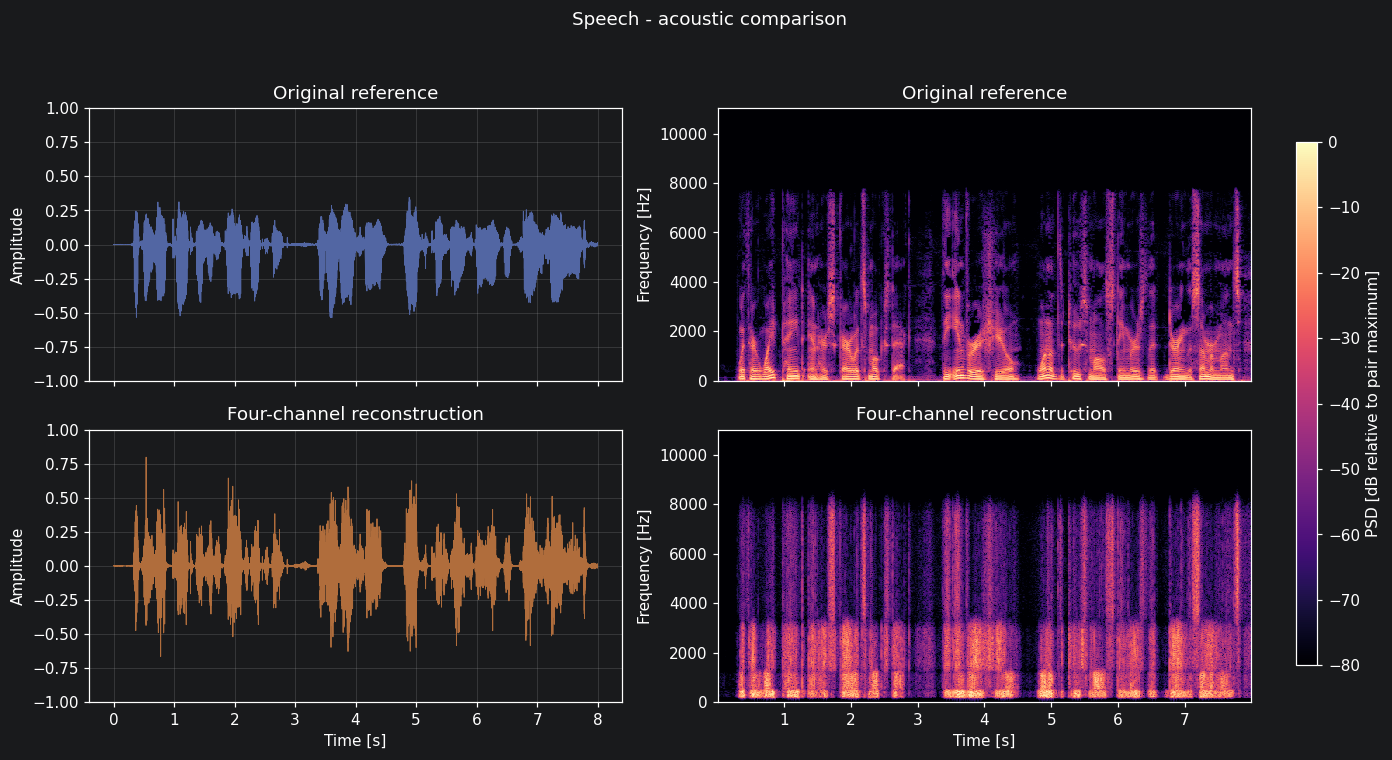

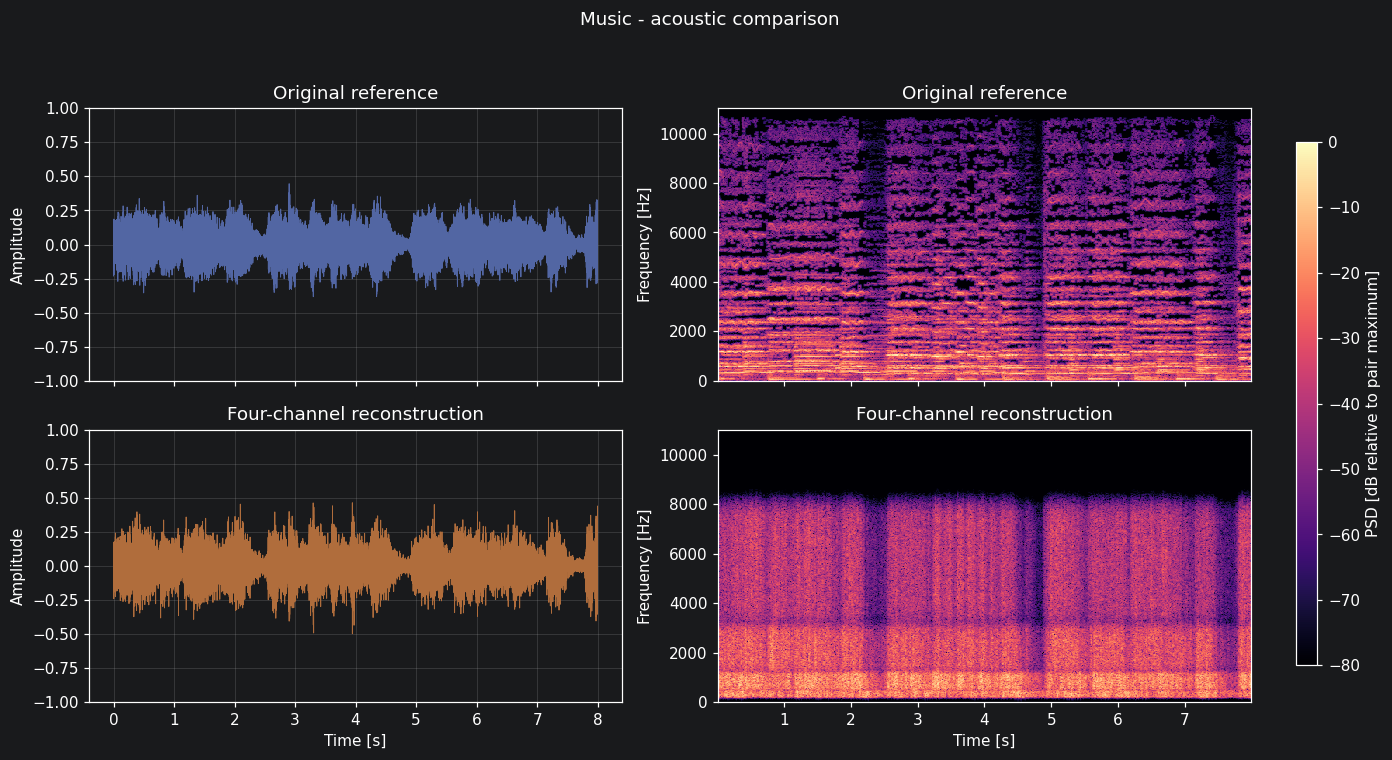

In [16]:
for name, record in records.items():
    reference = record["listening_reference"]
    reconstructed = record["listening_reconstruction"]
    fs = record["fs"]
    time = np.arange(len(reference)) / fs
    fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex="col")
    signals = [reference, reconstructed]
    labels = ["Original reference", "Four-channel reconstruction"]
    spectra = [spectrogram(signal, fs=fs, window="hann", nperseg=1024,
                           noverlap=768, detrend=False, scaling="density",
                           mode="psd") for signal in signals]
    power_reference = max(float(np.max(s[2])) for s in spectra)
    power_reference = max(power_reference, np.finfo(float).tiny)
    for row, (signal, label, spectrum) in enumerate(zip(signals, labels, spectra)):
        axes[row, 0].plot(time, signal, color=["#5266a3", "#b06d3c"][row], linewidth=0.6)
        axes[row, 0].set_title(label)
        axes[row, 0].set_ylabel("Amplitude")
        axes[row, 0].set_ylim(-1, 1)
        axes[row, 0].grid(alpha=0.25)
        frequency, frame_time, power = spectrum
        power_db = 10 * np.log10(np.maximum(power / power_reference, 1e-8))
        mesh = axes[row, 1].pcolormesh(
            frame_time, frequency, power_db, shading="auto",
            cmap="magma", vmin=-80, vmax=0
        )
        axes[row, 1].set_ylim(0, fs / 2)
        axes[row, 1].set_ylabel("Frequency [Hz]")
        axes[row, 1].set_title(label)
    for ax in axes[-1]:
        ax.set_xlabel("Time [s]")
    fig.suptitle(f"{name.capitalize()} - acoustic comparison")
    fig.tight_layout(rect=[0, 0, 0.89, 0.95])
    color_axis = fig.add_axes([0.91, 0.13, 0.015, 0.68])
    fig.colorbar(mesh, cax=color_axis, label="PSD [dB relative to pair maximum]")
    fig.savefig(OUTPUT_DIR / f"{name}_comparison.png", dpi=160)
    plt.show()
    plt.close(fig)

### 4.6 Export WAV files and reproducibility information

The exported WAV files are the same globally scaled signals used by the players.
Raw reconstructed arrays remain available in `records`. The JSON file records
the settings, playback gains and numerical envelope checks. Rerunning this cell
replaces the corresponding files inside `results/part3/`.

In [17]:
summary = {
    "base_commit": "19d23ee30922cd1a76abaeb40fc51b1827d00794",
    "audio_fs": AUDIO_FS, "band_edges_hz": BAND_EDGES,
    "filter_order": FILTER_ORDER, "envelope_cutoff_hz": ENVELOPE_CUTOFF,
    "alpha": ALPHA, "stimulation_fs": STIMULATION_FS,
    "pulse_rate_per_channel": PULSE_RATE,
    "phase_duration_us": PHASE_DURATION_US,
    "interphase_gap_us": INTERPHASE_GAP_US,
    "noise_seed": NOISE_SEED,
    "envelope_interpolation": "linear, nearest-value boundary hold",
    "wave_format": "PCM_16, RMS-matched pair with common peak attenuation",
    "examples": {name: {"librosa_example": example, "offset_s": offset}
                 for name, example, offset in examples},
    "checks": {},
}

for name, record in records.items():
    for label, signal in [("original", record["listening_reference"]),
                          ("reconstructed", record["listening_reconstruction"])]:
        assert np.all(np.isfinite(signal))
        assert np.max(np.abs(signal)) <= 0.9500001
        path = OUTPUT_DIR / f"{name}_{label}.wav"
        sf.write(path, signal, record["fs"], subtype="PCM_16")
        saved = sf.info(path)
        assert saved.frames == len(signal) and saved.samplerate == record["fs"]
        print(path.relative_to(PROJECT_ROOT))
    summary["checks"][name] = {
        "pulse_max_error": record["pulse_max_error"],
        "envelope_rmse_per_channel": record["envelope_rmse"],
        "playback_gains": record["playback_gains"],
        "input_samples": len(record["original"]),
    }

(OUTPUT_DIR / "reconstruction_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
print("Export complete.")

results/part3/speech_original.wav
results/part3/speech_reconstructed.wav
results/part3/music_original.wav
results/part3/music_reconstructed.wav
Export complete.


### 4.7 Interpretation and report notes

The numerical checks establish that the decoder reads the compressed samples
carried by the pulses and produces finite audio of the correct length. Envelope
RMSE measures agreement with the analysis envelopes. It does not measure how
well a listener understands a sentence.

For the report, add your observations after listening to both examples:

- Which words remain understandable? Is the rhythm of the speech preserved?
- For music, compare rhythm with pitch, melody and instrument identity.
- Relate these observations to the four broad bands and the replacement of
  temporal fine structure with noise.

The experiment does not include a neural model, electrode interactions,
patient-specific current thresholds or a clinical loudness map. More channels
are not guaranteed to reproduce an individual's hearing experience. These
limitations should remain explicit when connecting this work to the bonus game.

### References

- BME 576, *3.1 & 3.2*, CIS processing and auditory assignment.
- Shannon, R. V., Zeng, F.-G., Kamath, V., Wygonski, J., & Ekelid, M. (1995).
  *Speech Recognition with Primarily Temporal Cues*. Science, 270, 303-304.
  https://doi.org/10.1126/science.270.5234.303
- The alpha choice is inherited from the existing `src/compression.py`, citing
  López-Poveda et al. (2025), *Binaural audio frontend processing for cochlear
  implants inspired by the medial olivocochlear reflex*, Section 2.1.1, Eq. 1.
  https://doi.org/10.3389/fnins.2025.1678288

## 5. Interpretation and limitations

The numerical checks establish that the decoder reads the compressed samples carried by the pulses and produces finite audio of the expected length. Pulse-amplitude error measures decoding accuracy. Envelope RMSE measures agreement after interpolation. Neither metric measures speech intelligibility.

The noise vocoder preserves broad temporal envelope cues but replaces original phase and harmonic fine structure. The project also uses fixed bands, normalized simulation amplitudes, forward-backward filtering and a small set of example recordings. It does not model electrodes, current spread, neural excitation, patient-specific thresholds or clinical loudness.

### References

- BME 576, *3.1 & 3.2*, CIS processing and auditory assignment.
- Shannon, R. V., Zeng, F.-G., Kamath, V., Wygonski, J., & Ekelid, M. (1995). *Speech Recognition with Primarily Temporal Cues*. Science, 270, 303–304. https://doi.org/10.1126/science.270.5234.303
- López-Poveda, E. A. et al. (2025). *Binaural audio frontend processing for cochlear implants inspired by the medial olivocochlear reflex*. Section 2.1.1, Eq. 1. https://doi.org/10.3389/fnins.2025.1678288
